# APLICACIÓN DE K PROTOTYPES PARA LA OBTENCIÓN DE UNA CLASIFICACIÓN DE POBREZA ENERGÉTICA

**Autores** Luciano Altamirano, Gonzalo Pasiche

# Paso 0 - Carga de librerias y datos

In [1]:
!pip install prince kmodes -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score
import prince
from kmodes.kprototypes import KPrototypes
import warnings
warnings.filterwarnings("ignore")


#from google.colab import drive
#drive.mount("/content/drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.2/204.2 kB 5.3 MB/s eta 0:00:00


### Guía de Parámetros de KPrototypes

Aquí los argumentos más comunes para configurar el algoritmo:

*   **`n_clusters`**: El número de grupos (clusters) a formar.
*   **`init`**: Método de inicialización. Puede ser `'Huang'`, `'Cao'` (recomendado) o `'random'`.
*   **`n_init`**: Número de veces que el algoritmo se ejecutará con diferentes semillas para encontrar el mejor resultado.
*   **`gamma`**: Peso que equilibra las variables numéricas y categóricas. Si no se define, se calcula automáticamente como la media de las desviaciones estándar de las variables numéricas.
*   **`verbose`**: Si se establece en 1, muestra el progreso del costo en cada iteración.

In [2]:
# Ejecuta esta celda para ver la documentación técnica completa de la librería
help(KPrototypes)

Help on class KPrototypes in module kmodes.kprototypes:

class KPrototypes(kmodes.kmodes.KModes)
 |  KPrototypes(
 |      n_clusters=8,
 |      max_iter=100,
 |      num_dissim=<function euclidean_dissim at 0x7af2cb77e2a0>,
 |      cat_dissim=<function matching_dissim at 0x7af2cb77e0c0>,
 |      init='Cao',
 |      n_init=10,
 |      gamma=None,
 |      verbose=0,
 |      random_state=None,
 |      n_jobs=1
 |  )
 |
 |  k-protoypes clustering algorithm for mixed numerical/categorical data.
 |
 |  Parameters
 |  -----------
 |  n_clusters : int, optional, default: 8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |  max_iter : int, default: 100
 |      Maximum number of iterations of the k-modes algorithm for a
 |      single run.
 |
 |  num_dissim : func, default: euclidian_dissim
 |      Dissimilarity function used by the algorithm for numerical variables.
 |      Defaults to the Euclidian dissimilarity function.
 |
 |  cat_dissim : f

In [4]:
#ruta_bd = "/content/drive/MyDrive/Maestrías/Maestría Economía Aplicada UBA/Taller de programación/TP final/bd.dta"
#bd = pd.read_stata(ruta_bd)
bd = pd.read_stata("/content/bd.dta")
print(f"La base fue cargada correctamente: {bd.shape[0]} observaciones y {bd.shape[1]} variables.")

La base fue cargada correctamente: 31032 observaciones y 360 variables.


In [ ]:
bd.columns

Index(['id', 'aÑo', 'mes', 'conglome', 'vivienda', 'hogar', 'ubigeo',
       'dominio', 'estrato', 'periodo',
       ...
       'linea', 'linpe', 'percepho', 'v1', 'v2', 'v3', 'v4', 'v5', 'ci',
       'mepi'],
      dtype='object', length=360)

# Paso 1 - Selección de variables

In [5]:
# --- 1. Selección de variables y definición de grupos ---

acceso_energetico = [
    "p1121", "p1123", "p1124", "p1125", "p1126", "p1127",
    "p1131", "p1132", "p1133", "p1135", "p1136", "p1139",
    "p1137", "p113a", "p111a", "t110",
]

gasto_energetico = [
    "i1172_02", "i1172_04", "i1172_05",
    "i1172_06", "i1172_07", "i1172_08", "i1172_09",
]

socioeconomicas = [
    "gashog2d", "inghog2d", "mieperho", "percepho",
    "nbi1", "nbi2", "nbi3", "nbi4", "nbi5",
    "area", "pobreza",
]

vars_caracterizacion = [
    "linea", "linpe", "dominio", "estrato", "dep_2", "factor07",
]

# Paso 2 - Detección de correlación y missing

In [6]:
# --- 2. Diagnóstico de valores perdidos ---

etiquetas_variables = {
    "p1121": "Alumbrado por electricidad",
    "p1123": "Alumbrado: petróleo/gas",
    "p1124": "Alumbrado: vela",
    "p1125": "Alumbrado: generador",
    "p1126": "Alumbrado: otro",
    "p1127": "No utiliza alumbrado",
    "p1131": "Cocina con: electricidad",
    "p1132": "Cocina con: gas GLP",
    "p1133": "Cocina con: gas natural",
    "p1135": "Cocina con: carbón",
    "p1136": "Cocina con: leña",
    "p1139": "Cocina con: bosta/estiércol",
    "p1137": "Cocina con: otro",
    "p113a": "Combustible principal",
    "p111a": "Servicio higiénico",
    "t110":  "Abastecimiento de agua",
    "i1172_02": "Gasto electricidad",
    "i1172_04": "Gasto gas GLP",
    "i1172_05": "Gasto gas natural",
    "i1172_06": "Gasto vela",
    "i1172_07": "Gasto carbón",
    "i1172_08": "Gasto leña",
    "i1172_09": "Gasto petróleo",
    "gashog2d": "Gasto total bruto",
    "inghog2d": "Ingreso total bruto",
    "mieperho": "N° miembros hogar",
    "percepho": "N° perceptores ingreso",
    "nbi1": "NBI: vivienda inadecuada",
    "nbi2": "NBI: hacinamiento",
    "nbi3": "NBI: sin servicios higiénicos",
    "nbi4": "NBI: niños sin escuela",
    "nbi5": "NBI: dependencia económica",
    "area":    "Área urbana/rural",
    "pobreza": "Condición de pobreza",
}


2.1 Gráfico de missing

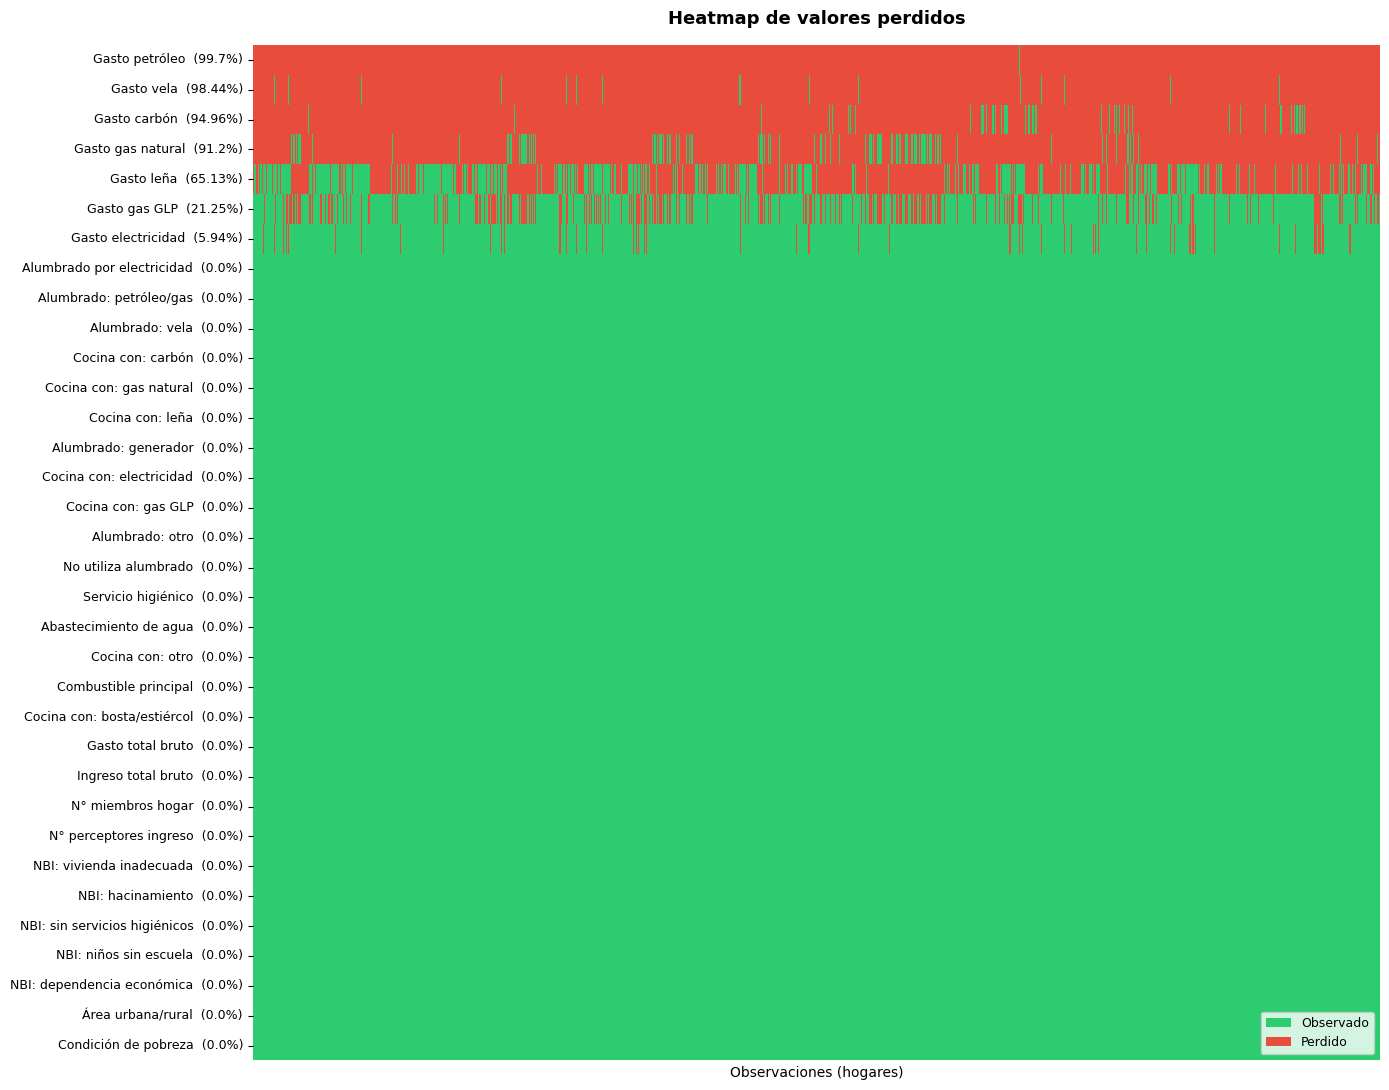

In [7]:
vars_clustering = acceso_energetico + gasto_energetico + socioeconomicas
bd_cluster = bd[vars_clustering].copy()

missing_pct = (bd_cluster.isnull().sum() / len(bd_cluster) * 100).round(2)
orden = missing_pct.sort_values(ascending=False).index
missing_matrix = bd_cluster[orden].isnull().astype(int)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    missing_matrix.T,
    cmap=["#2ecc71", "#e74c3c"],
    cbar=False,
    ax=ax,
    yticklabels=True,
    xticklabels=False
)
ax.set_yticklabels(
    [f"{etiquetas_variables.get(v, v)}  ({missing_pct[v]}%)" for v in orden],
    fontsize=9
)
ax.set_title("Heatmap de valores perdidos", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Observaciones (hogares)", fontsize=10)
ax.set_ylabel("")
ax.legend(
    handles=[Patch(facecolor="#2ecc71", label="Observado"), Patch(facecolor="#e74c3c", label="Perdido")],
    loc="lower right", fontsize=9
)
plt.tight_layout()
plt.show()


Porcentaje de missing

In [8]:
missing_resumen = pd.DataFrame({
    "Variable": gasto_energetico,
    "Missing": [bd[v].isnull().sum() for v in gasto_energetico],
    "% Missing": [(bd[v].isnull().sum() / len(bd) * 100).round(1) for v in gasto_energetico],
    "Descripción": [
        "Gasto electricidad",
        "Gasto gas GLP",
        "Gasto gas natural",
        "Gasto vela",
        "Gasto carbón",
        "Gasto leña",
        "Gasto petróleo/kerosene"
    ]
})

print(missing_resumen.to_string(index=False))

Variable  Missing  % Missing             Descripción
i1172_02     1844        5.9      Gasto electricidad
i1172_04     6593       21.2           Gasto gas GLP
i1172_05    28301       91.2       Gasto gas natural
i1172_06    30549       98.4              Gasto vela
i1172_07    29467       95.0            Gasto carbón
i1172_08    20211       65.1              Gasto leña
i1172_09    30940       99.7 Gasto petróleo/kerosene


* Verificación missing en variables de gasto mensual en i1172_02 (electricidad) y i1172_04 (GLP) y i1172_05 (GN)

In [9]:
print(bd[["i1172_02", "i1172_04", "i1172_05"]].isnull().sum())

i1172_02     1844
i1172_04     6593
i1172_05    28301
dtype: int64


* Se debe verificar que no existe casos en donde el hogar tenga acceso y a la vez no declare gastos
* Se comprubea que los hogares que declararon no tener acceso, son justamente lo que No declararon gasto
* En el caso de GN, el acceso es aún limitado, por ello es correcto que impute con valores ceros
Este proceso se hará en la siguiente sección

In [10]:
print("Missing en electricidad pero con acceso:")
print(bd[bd["i1172_02"].isnull() & (bd["p1121"] == "Electricidad")].shape[0])

print("Missing en GLP pero con acceso:")
print(bd[bd["i1172_04"].isnull() & (bd["p1132"] == "Gas GLP")].shape[0])

Missing en electricidad pero con acceso:
0
Missing en GLP pero con acceso:
0


2.2 Gráfico de correlación

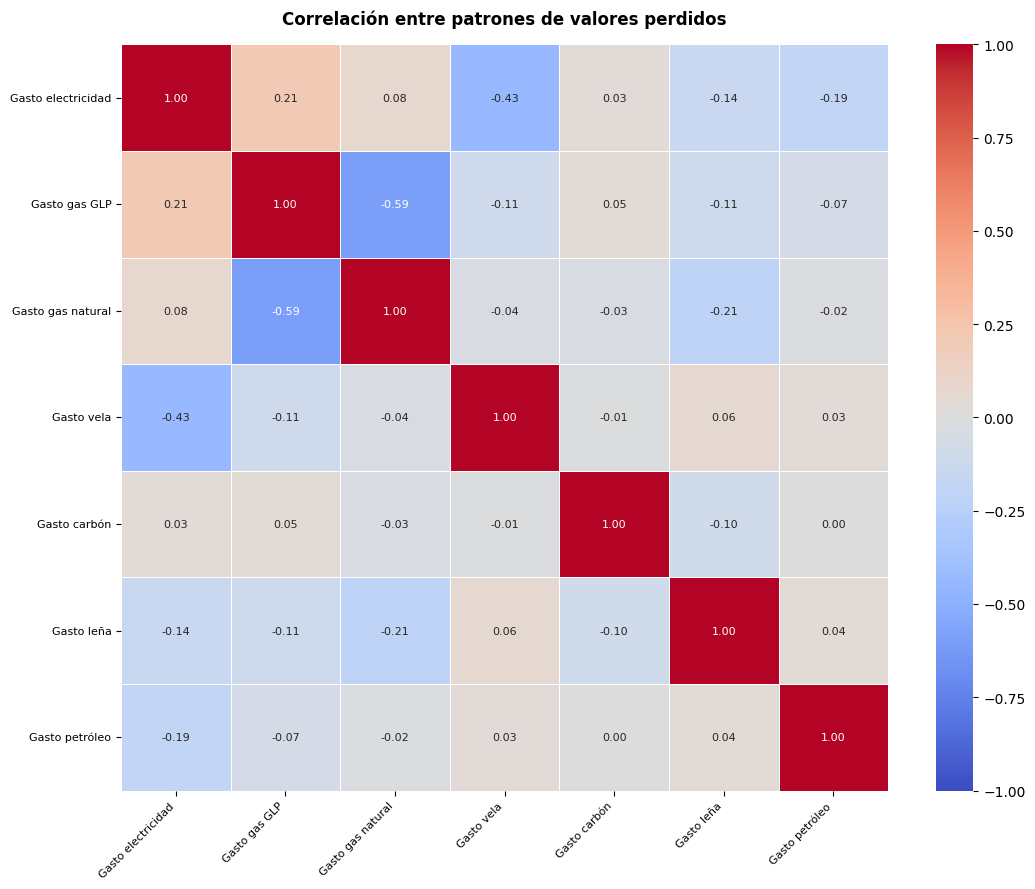

In [11]:
vars_con_missing = [v for v in vars_clustering if bd[v].isnull().any()]
corr_missing = bd[vars_con_missing].isnull().astype(int).corr()
corr_missing.index   = [etiquetas_variables.get(v, v) for v in corr_missing.index]
corr_missing.columns = [etiquetas_variables.get(v, v) for v in corr_missing.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_missing,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title("Correlación entre patrones de valores perdidos", fontsize=12, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Paso 3 - Construcción de variables derivadas

* Relleno con 0 en combustibles alternativos. La correlación del paso 2 va a mostrar que los missings de vela, carbón, leña y petróleo están altamente correlacionados entre sí y además coinciden con hogares que declaran tener electricidad (p1121=1). Eso indica que el hogar simplemente no usa esos combustibles, no que el dato sea desconocido. Imputar la media ahí sería un error: se estaría asignando un gasto en leña a un hogar urbano con electricidad.

* Proporción en lugar de gastos individuales. Meter los siete gastos energéticos por separado inflaría el peso del bloque de gasto en la distancia del modelo, porque cada combustible vota de forma independiente. La proporción los resume en una sola dimensión que además tiene interpretación directa para política pública: es la carga energética del hogar, la fracción del presupuesto que se va en energía.

* Control de infinitos. Cuando gashog2d es cero o muy pequeño la proporción explota. Se reemplaza por NaN para no contaminar el modelo con valores aberrantes.

In [16]:
# --- 3. Construcción de variables derivadas ---

combustibles_alternativos = ["i1172_06", "i1172_07", "i1172_08", "i1172_09"]
bd[combustibles_alternativos] = bd[combustibles_alternativos].fillna(0)

bd["prop_gasto_energetico"] = bd[gasto_energetico].sum(axis=1) / bd["gashog2d"]
bd["prop_gasto_energetico"] = bd["prop_gasto_energetico"].replace([np.inf, -np.inf], np.nan)

print(f"Hogares con proporción > 1: {(bd['prop_gasto_energetico'] > 1).sum()}")
print(f"Hogares con proporción missing: {bd['prop_gasto_energetico'].isnull().sum()}")

vars_clustering = acceso_energetico + ["prop_gasto_energetico"] + socioeconomicas

Hogares con proporción > 1: 0
Hogares con proporción missing: 0


# Parte 4 - Normalización

* Se usa RobustScaler en lugar de StandardScaler porque este escala usando la mediana y el rango intercuartílico en vez de la media y desviación estándar. Para variables de gasto e ingreso en encuestas de hogares eso es importante: la distribución es muy asimétrica y con colas pesadas, y StandardScaler se vería arrastrado por los hogares de ingreso muy alto. RobustScaler es más resistente a eso.

* Las categóricas no se tocan porque KPrototypes las maneja internamente con distancia de Hamming.

In [17]:
# --- 4. Normalización ---

vars_numericas = ["prop_gasto_energetico", "gashog2d", "inghog2d", "mieperho", "percepho"]
vars_categoricas = acceso_energetico + ["nbi1", "nbi2", "nbi3", "nbi4", "nbi5", "area", "pobreza"]

scaler = RobustScaler()
bd_num_scaled = pd.DataFrame(
    scaler.fit_transform(bd[vars_numericas]),
    columns=vars_numericas,
    index=bd.index
)

bd_modelo = pd.concat([bd_num_scaled, bd[vars_categoricas]], axis=1)
print(f"Shape final para el modelo: {bd_modelo.shape}")
print(f"Numéricas: {len(vars_numericas)} · Categóricas: {len(vars_categoricas)}")

Shape final para el modelo: (31032, 28)
Numéricas: 5 · Categóricas: 23


# Parte 5 - Selección de K

En los 3 casos analizados, el K optimo a trabajar es de k=3

In [18]:
# Se corre esto antes porque esta pregunta puede tener missing dado que en el
# hogar no se cocina:
if "No cocina" not in bd["p113a"].cat.categories:
    bd["p113a"] = bd["p113a"].cat.add_categories("No cocina")
bd["p113a"] = bd["p113a"].fillna("No cocina")

bd_modelo["p113a"] = bd["p113a"]

print(bd_modelo.isnull().sum().sum())

0


***Para tener en cuenta***

**CORRER LOS CASOS (a, b, c) TARDA BASTANTE MINUTOS**

a. Caso completo (el codigo tarda casi 1h) --> Ver si se corre

k=2 · costo=152422 · silueta=0.4679
k=3 · costo=134404 · silueta=0.2557
k=4 · costo=122785 · silueta=0.0339
k=5 · costo=111980 · silueta=-0.0471
k=6 · costo=105219 · silueta=-0.0379
k=7 · costo=98562 · silueta=-0.0627
k=8 · costo=94669 · silueta=-0.0707


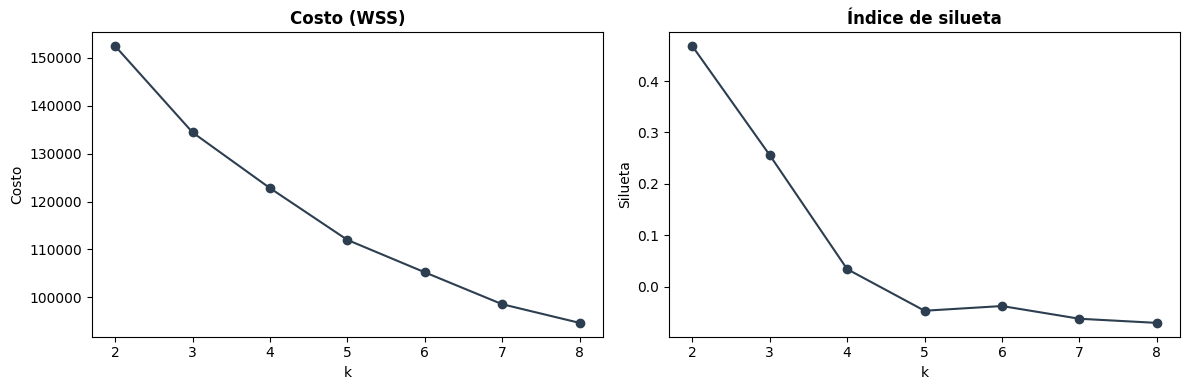

In [ ]:
# --- 5. Selección de k ---

# Por cuestiones de tiempo y ahorro de capacidad de computación se usó n_init=3

cat_cols_idx = [bd_modelo.columns.get_loc(c) for c in vars_categoricas]
X = bd_modelo.values

costos = []
siluetas = []
rango_k = range(2, 9)

for k in rango_k:
    kp = KPrototypes(n_clusters=k, init="Cao", n_init=3, random_state=42)
    labels = kp.fit_predict(X, categorical=cat_cols_idx)
    costos.append(kp.cost_)
    siluetas.append(silhouette_score(bd[vars_numericas], labels))
    print(f"k={k} · costo={kp.cost_:.0f} · silueta={siluetas[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rango_k, costos, marker="o", color="#2c3e50")
ax1.set_title("Costo (WSS)", fontweight="bold")
ax1.set_xlabel("k")
ax1.set_ylabel("Costo")

ax2.plot(rango_k, siluetas, marker="o", color="#2c3e50")
ax2.set_title("Índice de silueta", fontweight="bold")
ax2.set_xlabel("k")
ax2.set_ylabel("Silueta")

plt.tight_layout()
plt.show()

b. Caso de muestra por area y pobreza

k=2 · costo=47751 · silueta=0.3502
k=3 · costo=42164 · silueta=0.2578
k=4 · costo=37987 · silueta=0.2448
k=5 · costo=35083 · silueta=0.1682
k=6 · costo=32791 · silueta=0.1888
k=7 · costo=30822 · silueta=0.1741
k=8 · costo=29655 · silueta=0.1418


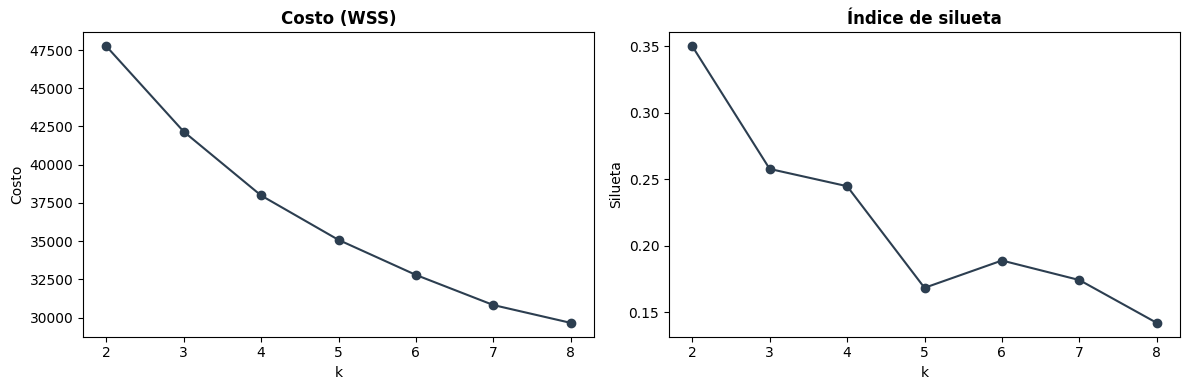

In [ ]:
bd_muestra = bd_modelo.groupby(
    [bd["area"], bd["pobreza"]], group_keys=False
).apply(lambda x: x.sample(frac=0.3, random_state=42))

X_muestra = bd_muestra.values
cat_cols_idx_muestra = [bd_muestra.columns.get_loc(c) for c in vars_categoricas]

costos = []
siluetas = []
rango_k = range(2, 9)

for k in rango_k:
    kp = KPrototypes(n_clusters=k, init="Cao", n_init=6, random_state=42)
    labels = kp.fit_predict(X_muestra, categorical=cat_cols_idx_muestra)
    costos.append(kp.cost_)
    siluetas.append(silhouette_score(bd_muestra[vars_numericas], labels))
    print(f"k={k} · costo={kp.cost_:.0f} · silueta={siluetas[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(rango_k, costos, marker="o", color="#2c3e50")
ax1.set_title("Costo (WSS)", fontweight="bold")
ax1.set_xlabel("k")
ax1.set_ylabel("Costo")

ax2.plot(rango_k, siluetas, marker="o", color="#2c3e50")
ax2.set_title("Índice de silueta", fontweight="bold")
ax2.set_xlabel("k")
ax2.set_ylabel("Silueta")

plt.tight_layout()
plt.show()

c. Caso con rango [2,3,4]

In [ ]:
# X y índices categóricos — consistente con tu bd_modelo
cat_cols_idx = [bd_modelo.columns.get_loc(c) for c in vars_categoricas]
X = bd_modelo.values

# Para la silueta usas las numéricas YA escaladas (están en bd_modelo)
X_num_scaled = bd_modelo[vars_numericas].values

costos = []
siluetas = []
rango_k = [2, 3, 4]

for k in rango_k:
    kp = KPrototypes(n_clusters=k, init="Cao", n_init=5, random_state=42)
    labels = kp.fit_predict(X, categorical=cat_cols_idx)

    costo = kp.cost_
    sil   = silhouette_score(X_num_scaled, labels)

    costos.append(costo)
    siluetas.append(sil)

    counts = pd.Series(labels).value_counts().sort_index()
    sizes  = " | ".join([f"C{i}: {n} ({n/len(labels)*100:.1f}%)" for i, n in counts.items()])

    print(f"k={k}  costo={costo:,.0f}  silueta={sil:.4f}  →  {sizes}")

k=2  costo=137,989  silueta=0.3480  →  C0: 21758 (70.1%) | C1: 9274 (29.9%)
k=3  costo=121,548  silueta=0.2520  →  C0: 15421 (49.7%) | C1: 3085 (9.9%) | C2: 12526 (40.4%)
k=4  costo=110,630  silueta=0.1607  →  C0: 12039 (38.8%) | C1: 2429 (7.8%) | C2: 11188 (36.1%) | C3: 5376 (17.3%)


# Paso 6 - Estimación de modelo final

De los casos analizados en el paso anterior se decidió optar
por un parámetero de K=3

In [21]:
bd_modelo["p113a"] = bd["p113a"]

# --- 6. Estimación del modelo final ---

cat_cols_idx = [bd_modelo.columns.get_loc(c) for c in vars_categoricas]
X = bd_modelo.values

kp_final = KPrototypes(n_clusters=3, init="Cao", n_init=5, random_state=42)
labels = kp_final.fit_predict(X, categorical=cat_cols_idx)

bd["cluster"] = labels

print(f"Costo final: {kp_final.cost_:.0f}")
print(f"\nDistribución de clusters:")
print(bd["cluster"].value_counts().sort_index())
print(f"\nProporción:")
print((bd["cluster"].value_counts(normalize=True).sort_index() * 100).round(1))

Costo final: 121548

Distribución de clusters:
cluster
0    15421
1     3085
2    12526
Name: count, dtype: int64

Proporción:
cluster
0    49.7
1     9.9
2    40.4
Name: proportion, dtype: float64


a.  De forma exploratoria - Que caracteriza a cada cluster

In [22]:
vars_perfil = ["prop_gasto_energetico", "gashog2d", "inghog2d", "mieperho"]

bd.groupby("cluster")[vars_perfil].mean().round(3)

,prop_gasto_energetico,gashog2d,inghog2d,mieperho
cluster,,,,
0,0.050,17709.394,20725.520,2.097
1,0.029,75831.455,116601.394,4.680
2,0.033,34365.400,42364.704,4.270


In [23]:
bd.groupby("cluster")[["pobreza", "area", "p1121", "p113a"]].agg(lambda x: x.value_counts().index[0])

,pobreza,area,p1121,p113a
cluster,,,,
0,No Pobre,urbana,Electricidad,Gas GLP
1,No Pobre,urbana,Electricidad,Gas GLP
2,No Pobre,urbana,Electricidad,Gas GLP


b. De forma más general - qué caracteriza a cada clúster:

In [24]:
perfil_num = bd.groupby("cluster")[vars_numericas].mean().round(3)
print(perfil_num)

perfil_cat = bd.groupby("cluster")[vars_categoricas].agg(
    lambda x: x.value_counts().index[0]
)
print(perfil_cat)

# Define the NBI columns
nbi_cols_list = ["nbi1", "nbi2", "nbi3", "nbi4", "nbi5"]

# Create a temporary DataFrame for NBI calculations to avoid modifying original 'bd'
bd_nbi_for_mean = bd[nbi_cols_list + ["cluster"]].copy()

# Convert NBI categorical columns to numerical (0 for non-NBI, 1 for NBI)
# The `perfil_cat` output shows the *most frequent* category, which represents the *absence* of the NBI condition.
# We map this 'absence' state to 0 and the 'presence' state to 1.
for col in nbi_cols_list:
    # Get the most frequent category (absence of NBI) for the current column
    non_nbi_state = perfil_cat.loc[0, col] # Assuming cluster 0's mode is representative for the 'non-NBI' state
    bd_nbi_for_mean[col] = bd_nbi_for_mean[col].apply(lambda x: 0 if x == non_nbi_state else 1).astype(int)

perfil_nbi = bd_nbi_for_mean.groupby("cluster")[nbi_cols_list].mean().round(3)
print(perfil_nbi)

         prop_gasto_energetico   gashog2d    inghog2d  mieperho  percepho
cluster                                                                  
0                        0.050  17709.394   20725.520     2.097     1.380
1                        0.029  75831.455  116601.394     4.680     3.168
2                        0.033  34365.400   42364.704     4.270     2.505
                p1121 p1123 p1124 p1125 p1126 p1127 p1131    p1132 p1133  \
cluster                                                                    
0        Electricidad  Pase  Pase  Pase  Pase  Pase  Pase  Gas GLP  Pase   
1        Electricidad  Pase  Pase  Pase  Pase  Pase  Pase  Gas GLP  Pase   
2        Electricidad  Pase  Pase  Pase  Pase  Pase  Pase  Gas GLP  Pase   

        p1135  ...    p113a                                         p111a  \
cluster        ...                                                          
0        Pase  ...  Gas GLP  Red publica de desagüe dentro de la vivienda   
1        Pase  ...

b.1 Se verifica como se interpreta cada cluster hallad

In [25]:
resumen_clusters = pd.DataFrame({
    "Ingreso promedio (S/)":            perfil_num["inghog2d"].round(0),
    "Gasto total promedio (S/)":        perfil_num["gashog2d"].round(0),
    "Carga energética (%)":             (perfil_num["prop_gasto_energetico"] * 100).round(1),
    "N° miembros":                      perfil_num["mieperho"].round(1),
    "N° perceptores":                   perfil_num["percepho"].round(1),
    "NBI1 - Vivienda inadecuada (%)":   (perfil_nbi["nbi1"] * 100).round(1),
    "NBI2 - Hacinamiento (%)":          (perfil_nbi["nbi2"] * 100).round(1),
    "NBI3 - Saneamiento (%)":           (perfil_nbi["nbi3"] * 100).round(1),
    "NBI4 - Escolaridad (%)":           (perfil_nbi["nbi4"] * 100).round(1),
    "NBI5 - Dependencia económica (%)": (perfil_nbi["nbi5"] * 100).round(1),
    "Tiene electricidad (%)":           (bd.groupby("cluster")["p1121"].apply(lambda x: (x == "Electricidad").mean()) * 100).round(1),
    "Cocina con GLP (%)":               (bd.groupby("cluster")["p1132"].apply(lambda x: (x == "Gas GLP").mean()) * 100).round(1),
    "Área urbana (%)":                  (bd.groupby("cluster")["area"].apply(lambda x: (x == "urbana").mean()) * 100).round(1),
    "No pobre (%)":                     (bd.groupby("cluster")["pobreza"].apply(lambda x: (x == "No Pobre").mean()) * 100).round(1),
    "N° hogares":                       bd.groupby("cluster")["cluster"].count(),
    "% del total":                      (bd.groupby("cluster")["cluster"].count() / len(bd) * 100).round(1),
})

resumen_clusters.index = [
    "Cluster 0: Bajos ingresos, alta carga energética",
    "Cluster 1: Altos ingresos, baja carga energética",
    "Cluster 2: Ingresos medios, carga moderada"
]

print(resumen_clusters.T.to_string())

                                  Cluster 0: Bajos ingresos, alta carga energética  Cluster 1: Altos ingresos, baja carga energética  Cluster 2: Ingresos medios, carga moderada
Ingreso promedio (S/)                                                      20726.0                                          116601.0                                     42365.0
Gasto total promedio (S/)                                                  17709.0                                           75831.0                                     34365.0
Carga energética (%)                                                           5.0                                               2.9                                         3.3
N° miembros                                                                    2.1                                               4.7                                         4.3
N° perceptores                                                                 1.4                                 

* No se verifica diferencias en la moda de variables categóricas de acceso energético.
* Por ejemplo: acceso a electricidad o cocina con GLP, casi no varía entre
clusters.
* Para ello se verifa el parámetro gamma, si esta es muy baja entonces es posible que el algoritmo halla ignorado las categóricas para la segmentación por clústers. Otra opción es que la composición de la base tenga sesgo hacia determinado grupo, lo cual tendría el mismo desenlace, el algoritmo no considera de forma preponderante a las variables categóricas, lo cual responde justamente al problema analizada, donde se trata de construir un indicador más preciso que vaya más allá de variables de acceso.




In [26]:
print(f"Gamma utilizado: {kp_final.gamma}")

Gamma utilizado: 0.4779112861802292


El siguiente paso es verificar que la muestra tiene sesgo, las variables estan concentradas en determinado grupo (electricidad, uso de GLP o area urbana)

* Por ello K prototypes solo esta encontrando diferencias en variables numéricas --> lo que es justanmente lo que MEPI no captura y es parte de la crítica

In [27]:
print(bd[["p1121", "p1132", "area"]].apply(lambda x: x.value_counts(normalize=True).head(2)))

                 p1121     p1132      area
Electricidad  0.940577       NaN       NaN
Gas GLP            NaN  0.787542       NaN
Pase          0.059423  0.212458       NaN
rural              NaN       NaN  0.283417
urbana             NaN       NaN  0.716583


# Paso 7 - Análsis de sensibilidad

* Se analiza si una variable por si sola esta siendo preponderante para la segmentación de clúster

* Si la digonal es 1, significa que las hogares se mantienen en el clúster establecido

* El razonamiento teórico, nos dice que tanto la carga presupuestal energética como los ingresos declarados pueden ser muy rel

In [28]:
# --- 7. Análisis de sensibilidad ---

configuraciones = [
    {"vars_num": vars_numericas, "desc": "base"},
    {"vars_num": [v for v in vars_numericas if v != "prop_gasto_energetico"], "desc": "sin proporción"},
    {"vars_num": [v for v in vars_numericas if v != "inghog2d"], "desc": "sin ingreso"},
]

for cfg in configuraciones:
    X_sens = pd.concat([bd_num_scaled[cfg["vars_num"]], bd[vars_categoricas]], axis=1).values
    cat_idx_sens = list(range(len(cfg["vars_num"]), len(cfg["vars_num"]) + len(vars_categoricas)))

    kp_sens = KPrototypes(n_clusters=3, init="Cao", n_init=5, random_state=42)
    labels_sens = kp_sens.fit_predict(X_sens, categorical=cat_idx_sens)

    dist = pd.crosstab(bd["cluster"], labels_sens, normalize="index").round(2)
    print(f"\nConfiguración: {cfg['desc']}")
    print(dist)

KeyboardInterrupt: 

# Paso 8 - Perfilamiento y uso de factor de expansión

In [29]:
print(bd["factor07"].describe().round(2))
print(f"\nTipo: {bd['factor07'].dtype}")

count    31032.00
mean       305.04
std        306.44
min          1.66
25%        120.35
50%        226.57
75%        368.21
max       1845.74
Name: factor07, dtype: float64

Tipo: float64


In [30]:
nbi_no_carencia = {
    "nbi1": "Vivienda adecuada",
    "nbi2": "Vivienda sin hacinamiento",
    "nbi3": "Hogares con vivienda con servicios higienicos",
    "nbi4": "Hogares con niños que asisten a la escuela",
    "nbi5": "Hogares sin alta dependencia economica"
}

for col, estado in nbi_no_carencia.items():
    bd[f"{col}_num"] = (bd[col] != estado).astype(int)

In [31]:
# --- 8. Perfilamiento e interpretación ---

def media_ponderada(grupo, var, peso):
    return np.average(grupo[var], weights=grupo[peso])

perfil_pond = bd.groupby("cluster").apply(lambda g: pd.Series({
    "Ingreso promedio (S/)":          round(media_ponderada(g, "inghog2d", "factor07"), 0),
    "Gasto total promedio (S/)":      round(media_ponderada(g, "gashog2d", "factor07"), 0),
    "Carga energética (%)":           round(media_ponderada(g, "prop_gasto_energetico", "factor07") * 100, 1),
    "N° miembros":                    round(media_ponderada(g, "mieperho", "factor07"), 1),
    "N° perceptores":                 round(media_ponderada(g, "percepho", "factor07"), 1),
    "NBI1 - Vivienda inadecuada (%)": round(media_ponderada(g, "nbi1_num", "factor07") * 100, 1),
    "NBI2 - Hacinamiento (%)":        round(media_ponderada(g, "nbi2_num", "factor07") * 100, 1),
    "NBI3 - Saneamiento (%)":         round(media_ponderada(g, "nbi3_num", "factor07") * 100, 1),
    "NBI4 - Escolaridad (%)":         round(media_ponderada(g, "nbi4_num", "factor07") * 100, 1),
    "NBI5 - Dependencia econ. (%)":   round(media_ponderada(g, "nbi5_num", "factor07") * 100, 1),
    "Tiene electricidad (%)":         round((g["p1121"] == "Electricidad").mean() * 100, 1),
    "Cocina con GLP (%)":             round((g["p1132"] == "Gas GLP").mean() * 100, 1),
    "Área urbana (%)":                round((g["area"] == "urbana").mean() * 100, 1),
    "No pobre (%)":                   round((g["pobreza"] == "No Pobre").mean() * 100, 1),
}))

perfil_pond.index = [
    "Cluster 0: Bajos ingresos, alta carga",
    "Cluster 1: Altos ingresos, baja carga",
    "Cluster 2: Ingresos medios, carga moderada"
]

print(perfil_pond.T.to_string())

print("\nDistribución por pobreza monetaria (%):")
print(pd.crosstab(bd["cluster"], bd["pobreza"], normalize="index").round(3) * 100)

print("\nDistribución por dominio (%):")
print(pd.crosstab(bd["cluster"], bd["dominio"], normalize="index").round(3) * 100)

print("\nTamaño ponderado de clusters:")
pond = bd.groupby("cluster")["factor07"].sum()
print((pond / pond.sum() * 100).round(1))

                                Cluster 0: Bajos ingresos, alta carga  Cluster 1: Altos ingresos, baja carga  Cluster 2: Ingresos medios, carga moderada
Ingreso promedio (S/)                                         21305.0                               117171.0                                     43710.0
Gasto total promedio (S/)                                     18480.0                                75494.0                                     35266.0
Carga energética (%)                                              5.1                                    2.9                                         3.4
N° miembros                                                       2.1                                    4.8                                         4.2
N° perceptores                                                    1.4                                    3.3                                         2.5
NBI1 - Vivienda inadecuada (%)                                    6.5             

# Paso 9 - Visualización de resultados

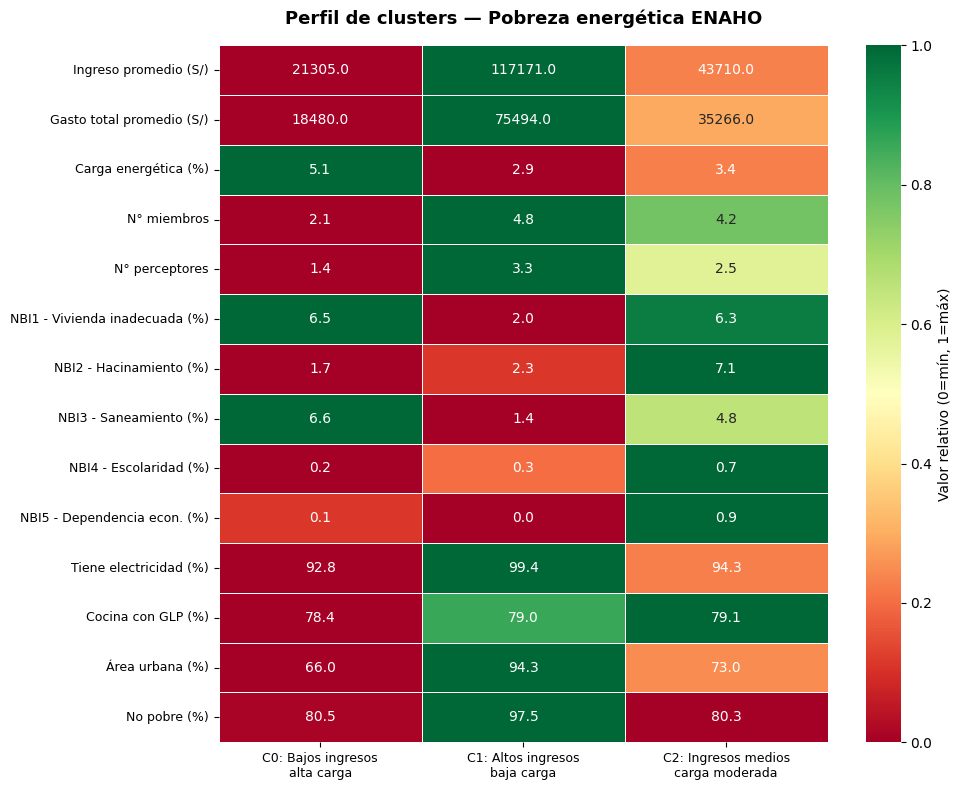

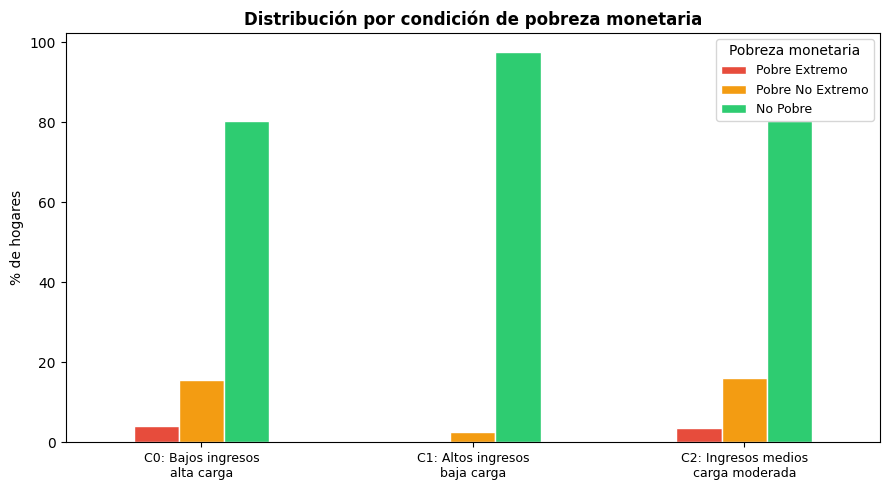

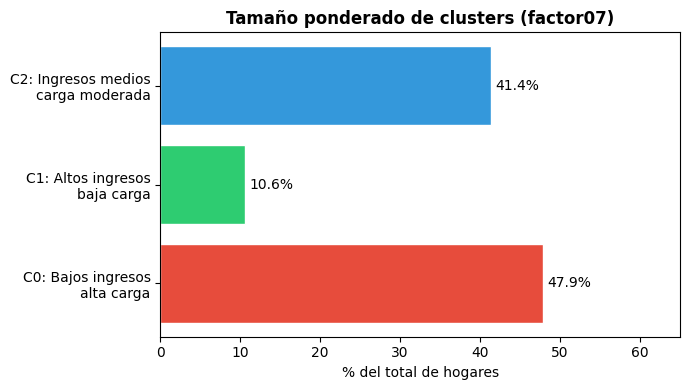

In [32]:
# --- 9. Visualización y reporte ---

nombres_clusters = [
    "C0: Bajos ingresos\nalta carga",
    "C1: Altos ingresos\nbaja carga",
    "C2: Ingresos medios\ncarga moderada"
]

colores = ["#e74c3c", "#2ecc71", "#3498db"]

# Heatmap de centroides
vars_heatmap = [
    "Ingreso promedio (S/)", "Gasto total promedio (S/)", "Carga energética (%)",
    "N° miembros", "N° perceptores",
    "NBI1 - Vivienda inadecuada (%)", "NBI2 - Hacinamiento (%)",
    "NBI3 - Saneamiento (%)", "NBI4 - Escolaridad (%)", "NBI5 - Dependencia econ. (%)",
    "Tiene electricidad (%)", "Cocina con GLP (%)", "Área urbana (%)", "No pobre (%)"
]

perfil_norm = perfil_pond[vars_heatmap].T
perfil_norm = (perfil_norm - perfil_norm.min(axis=1).values.reshape(-1, 1)) / \
              (perfil_norm.max(axis=1) - perfil_norm.min(axis=1)).values.reshape(-1, 1)
perfil_norm.columns = nombres_clusters

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    perfil_norm,
    annot=perfil_pond[vars_heatmap].T.values,
    fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Valor relativo (0=mín, 1=máx)"}
)
ax.set_title("Perfil de clusters — Pobreza energética ENAHO", fontsize=13, fontweight="bold", pad=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
plt.tight_layout()
plt.show()

# Gráfico de barras por pobreza monetaria
pobreza_dist = pd.crosstab(bd["cluster"], bd["pobreza"], normalize="index") * 100
pobreza_dist.index = nombres_clusters

fig, ax = plt.subplots(figsize=(9, 5))
pobreza_dist.plot(kind="bar", ax=ax, color=["#e74c3c", "#f39c12", "#2ecc71"], edgecolor="white")
ax.set_title("Distribución por condición de pobreza monetaria", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("% de hogares")
ax.set_xticklabels(nombres_clusters, rotation=0, fontsize=9)
ax.legend(title="Pobreza monetaria", fontsize=9)
plt.tight_layout()
plt.show()

# Tamaño ponderado de clusters
pond_pct = (bd.groupby("cluster")["factor07"].sum() / bd["factor07"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(nombres_clusters, pond_pct.values, color=colores, edgecolor="white")
for bar, val in zip(bars, pond_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=10)
ax.set_title("Tamaño ponderado de clusters (factor07)", fontsize=12, fontweight="bold")
ax.set_xlabel("% del total de hogares")
ax.set_xlim(0, 65)
plt.tight_layout()
plt.show()

# Parte 10 - Comparación con variable MEPI

In [ ]:
print(bd["mepi"].value_counts())
print(bd["mepi"].dtype)

mepi
0.0    21375
1.0     9657
Name: count, dtype: int64
float64


Distribución MEPI:
mepi
0    68.9
1    31.1
Name: proportion, dtype: float64

Cruce cluster vs MEPI (%):
                                     No pobre energético (MEPI)  \
C0: Bajos ingresos, alta carga                             62.7   
C1: Altos ingresos, baja carga                             94.8   
C2: Ingresos medios, carga moderada                        70.0   

                                     Pobre energético (MEPI)  
C0: Bajos ingresos, alta carga                          37.3  
C1: Altos ingresos, baja carga                           5.2  
C2: Ingresos medios, carga moderada                     30.0  

Cruce MEPI vs cluster (%):
                            C0: Bajos ingresos, alta carga  \
No pobre energético (MEPI)                            45.3   
Pobre energético (MEPI)                               59.5   

                            C1: Altos ingresos, baja carga  \
No pobre energético (MEPI)                            13.7   
Pobre energético (MEPI)            

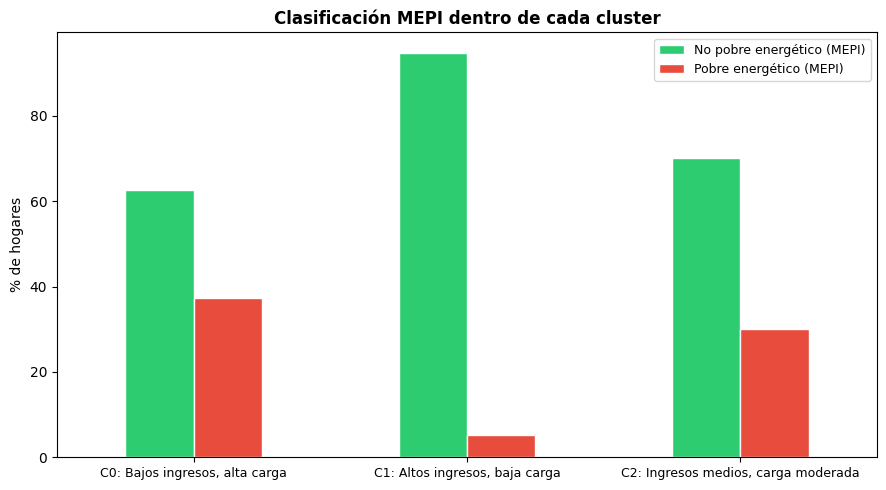

In [ ]:
# --- 10. Comparación con MEPI ---

bd["mepi"] = bd["mepi"].astype(int)

print("Distribución MEPI:")
print((bd["mepi"].value_counts(normalize=True) * 100).round(1))

print("\nCruce cluster vs MEPI (%):")
cruce = pd.crosstab(bd["cluster"], bd["mepi"], normalize="index") * 100
cruce.columns = ["No pobre energético (MEPI)", "Pobre energético (MEPI)"]
cruce.index = [
    "C0: Bajos ingresos, alta carga",
    "C1: Altos ingresos, baja carga",
    "C2: Ingresos medios, carga moderada"
]
print(cruce.round(1))

print("\nCruce MEPI vs cluster (%):")
cruce2 = pd.crosstab(bd["mepi"], bd["cluster"], normalize="index") * 100
cruce2.index = ["No pobre energético (MEPI)", "Pobre energético (MEPI)"]
cruce2.columns = [
    "C0: Bajos ingresos, alta carga",
    "C1: Altos ingresos, baja carga",
    "C2: Ingresos medios, carga moderada"
]
print(cruce2.round(1))

invisibles = bd[(bd["mepi"] == 0) & (bd["cluster"] == 0)]
print(f"\nHogares invisibles para MEPI pero en cluster vulnerable (C0): {len(invisibles)}")
print(f"Como % del total: {len(invisibles)/len(bd)*100:.1f}%")
print(f"Ingreso promedio de invisibles: S/ {invisibles['inghog2d'].mean():.0f}")
print(f"Carga energética promedio: {invisibles['prop_gasto_energetico'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
cruce.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="white")
ax.set_title("Clasificación MEPI dentro de cada cluster", fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("% de hogares")
ax.set_xticklabels(cruce.index, rotation=0, fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()